In [62]:
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.patches as patches


from simulation.camera_model      import get_K, get_camera_pose
from simulation.projection        import project_points, filter_visible
from simulation.homography        import homography, decompose_H
from eight_points.eight_point_agl import eight_point
from eight_points.Retrieve_P      import get_R_t_from_epipolar, P_estimation, parallax, find_scaling_factor
from eight_points.RANSAC          import RANSAC, score_H_RANSAC, score_F_RANSAC
from pipeline.score               import score_H, score_F
from eight_points.triangulation   import triangulate
from simulation.scene_urban       import generate_urban_scene

def residual_F(px1, px2, F):
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])
    # Epipolar lines
    Fx1  = F @ h1                                             # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)
    num = np.sum(h2 * Fx1, axis=0) ** 2
    denom1 = Fx1[0]**2 + Fx1[1]**2                            # (N,)
    denom2 = Ftx2[0]**2 + Ftx2[1]**2                          # (N,)
    d2_sym = num * (1.0 / (denom1 + 1e-12) + 1.0 / (denom2 + 1e-12))
    total_error = 1/N * np.sum(d2_sym)
    return total_error


def make_scene(
    n_points=1000, 
    scene_type='3d', 
    x_range=2.0, 
    y_range=1.5, 
    z_min=5.0, 
    z_max=15.0,
    fx=1000.0, fy=1000.0, cx=960.0, cy=540.0, 
    img_w=1920, img_h=1080,
    cam1_rx=0.0, cam1_ry=0.0, cam1_rz=0.0, cam1_tx=0.0, cam1_ty=0.0, cam1_tz=0.0,
    cam2_rx=0.0, cam2_ry=8.0, cam2_rz=0.0, cam2_tx=1.5, cam2_ty=0, cam2_tz=0.0,
    noise_sigma=1.0, 
    outlier_ratio=0.1,
    seed=42,
    dispersion = None
):
    """
    Generates a synthetic scene seen by two cameras.
    Returns a dict: pts3d, px1, px2, K, R_rel, t_rel, R1, t1.
    """
    rng = np.random.default_rng(seed)

    # 1. Generate 3D Points
    if scene_type == "urban":
        pts3d, _= generate_urban_scene(rng, n_points)
    else:
        xs = rng.uniform(-x_range, x_range, n_points)
        ys = rng.uniform(-y_range, y_range, n_points)
        if dispersion is not None:
            # 1. Generate random angles between 0 and 2π
            angles = rng.uniform(0, 2 * np.pi, n_points)
            
            # 2. Generate random radii
            # CRITICAL: You must take the square root of the random uniform value!
            # If you don't, your points will cluster heavily in the exact center.
            radii = dispersion * np.sqrt(rng.uniform(0, 1, n_points))
            
            # 3. Convert polar coordinates (radius, angle) back to Cartesian (X, Y)
            xs = radii * np.cos(angles)
            ys = radii * np.sin(angles)

        if scene_type == 'planar':
            zs = np.full(n_points, z_min)
        else:
            lo, hi = min(z_min, z_max), max(z_min, z_max)
            zs = rng.uniform(lo, hi, n_points)
        pts3d = np.vstack([xs, ys, zs])
    
    # 2. Camera Intrinsics
    K = np.array([[fx,  0, cx],
                  [ 0, fy, cy],
                  [ 0,  0,  1]], dtype=np.float64)

    # 3. Camera Poses (Extrinsics)
    R1, t1 = get_camera_pose(cam1_rx, cam1_ry, cam1_rz,
                             cam1_tx, cam1_ty, cam1_tz)
    R2, t2 = get_camera_pose(cam2_rx, cam2_ry, cam2_rz,
                             cam2_tx, cam2_ty, cam2_tz)

    R_rel = R2 @ R1.T
    t_rel = t2 - R_rel @ t1

    # 4. Project and Filter Visible Points
    px1_c, d1 = project_points(pts3d, K, R1, t1)
    px2_c, d2 = project_points(pts3d, K, R2, t2)
    
    vis = (filter_visible(px1_c, d1, img_w, img_h) &
           filter_visible(px2_c, d2, img_w, img_h))

    px1 = px1_c[:, vis].copy()
    px2 = px2_c[:, vis].copy()
    M   = px1.shape[1]

    # 5. Inject Gaussian Noise
    if noise_sigma > 0 and M > 0:
        nrng = np.random.default_rng(seed + 1000)
        px1 += nrng.normal(0, noise_sigma, px1.shape)
        px2 += nrng.normal(0, noise_sigma, px2.shape)

    # 6. Inject Outliers (False Matches)
    if outlier_ratio > 0 and M > 0:
        orng  = np.random.default_rng(seed + 2000)
        n_out = min(max(1, int(round(M * outlier_ratio))), M)
        idx   = orng.choice(M, n_out, replace=False)
        px2[0, idx] = orng.uniform(0, img_w, n_out)
        px2[1, idx] = orng.uniform(0, img_h, n_out)

    return {
        'pts3d': pts3d[:, vis], 
        'px1': px1, 
        'px2': px2,
        'K': K, 
        'R_rel': R_rel, 
        't_rel': t_rel,
        'R1': R1, 
        't1': t1,
        'd1': d1
    }

def _rot_err(R_est, R_ref):
    tr = np.trace(R_est.T @ R_ref)
    return np.degrees(np.arccos(np.clip((tr - 1) / 2, -1, 1)))


def _trans_err(t_est, t_ref):
    u = t_est / (np.linalg.norm(t_est) + 1e-12)
    v = t_ref / (np.linalg.norm(t_ref) + 1e-12)
    return np.degrees(np.arccos(np.clip(abs(np.dot(u, v)), 0, 1)))

def _trans_mag_err(t_est, t_ref):
    return np.linalg.norm(t_ref - t_est)

def get_dsamp_F(F, px1, px2, threshold=3.84):
    """
    Symmetric Sampson distance score for fundamental matrix F (ORB-SLAM style).

    Sampson distance is the first-order approximation of the reprojection error
    under the epipolar constraint x2ᵀFx1 = 0 :

      d²_sampson = (x2ᵀFx1)² / (‖Fx1‖²_top2 + ‖Fᵀx2‖²_top2)

      S_F = Σ max(0, T - d²_sampson)

    threshold : chi² at 95% for 1 DOF = 3.84  (epipolar constraint is 1D)

    Returns: float  (higher = better fit)
    """
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])
    h2 = np.vstack([px2, np.ones((1, N))])

    Fx1  = F @ h1                                              # (3, N)
    Ftx2 = F.T @ h2                                           # (3, N)

    num      = np.sum(h2 * Fx1, axis=0) ** 2                  # (x2ᵀFx1)²
    denom    = Fx1[0]**2 + Fx1[1]**2 + Ftx2[0]**2 + Ftx2[1]**2
    d_samp   = num / (denom + 1e-12)
    return d_samp

def get_dsamp_H(H, px1, px2, threshold=3.84):
    """
    Symmetric Sampson distance score for fundamental matrix F (ORB-SLAM style).

    Sampson distance is the first-order approximation of the reprojection error
    under the epipolar constraint x2ᵀFx1 = 0 :

      d²_sampson = (x2ᵀFx1)² / (‖Fx1‖²_top2 + ‖Fᵀx2‖²_top2)

      S_F = Σ max(0, T - d²_sampson)

    threshold : chi² at 95% for 1 DOF = 3.84  (epipolar constraint is 1D)

    Returns: float  (higher = better fit)
    """
    N = px1.shape[1]
    h1 = np.vstack([px1, np.ones((1, N))])   # (3, N)
    h2 = np.vstack([px2, np.ones((1, N))])   # (3, N)

    # Forward: H · px1 → px2
    p12 = H @ h1
    p12 = p12[:2] / p12[2]
    d12 = np.sum((p12 - px2) ** 2, axis=0)

    # Backward: H⁻¹ · px2 → px1
    p21 = np.linalg.inv(H) @ h2
    p21 = p21[:2] / p21[2]
    d21 = np.sum((p21 - px1) ** 2, axis=0)
    d_samp = d12 + d21
    return d_samp

def get_angles_from_matrix(R):
    # Extract ry (theta)
    # Note: this assumes the matrix is not in a "Gimbal Lock" state (ry != 90 or -90 deg)
    ry = np.arcsin(-R[2, 0])
    
    # Extract rx (phi)
    rx = np.arctan2(R[2, 1], R[2, 2])
    
    # Extract rz (psi)
    rz = np.arctan2(R[1, 0], R[0, 0])
    
    # Convert from radians to degrees
    return np.degrees([rx, ry, rz])

def residual_H(H, px1, px2, type = "One image"):
    N = px1.shape[1]
    
    # Convert to homogeneous coordinates
    h1 = np.vstack([px1, np.ones((1, N))])   # (3, N)
    h2 = np.vstack([px2, np.ones((1, N))])   # (3, N)

    # Forward: H · px1 → px2
    p12 = H @ h1
    p12 = p12[:2] / p12[2] # Dehomogenization
    # Sum over ALL dimensions (both x/y and all N points)
    sum_d12 = np.sum((p12 - px2) ** 2) 

    if type == "One image":
        # Equation 5.1 from the textbook
        res_H = np.sqrt(1 / (2 * N) * sum_d12)
        
    else:
        # Backward: H⁻¹ · px2 → px1
        p21 = np.linalg.inv(H) @ h2
        p21 = p21[:2] / p21[2] # Dehomogenization
        sum_d21 = np.sum((p21 - px1) ** 2)
        
        # Symmetric transfer error
        res_H = np.sqrt(1 / (4 * N) * (sum_d12 + sum_d21))
        
    return res_H

def translate_point(point, translation_vector):
    """
    Translates a 3D point using simple vector addition.
    Both inputs should be [x, y, z] arrays or lists.
    """
    # Ensure both inputs are NumPy arrays for element-wise addition
    P = np.array(point)
    T = np.array(translation_vector)
    
    # Add the arrays together: [x+tx, y+ty, z+tz]
    P_new = P + T
    
    return P_new

def generate_regular_polygon(n, r, cx=0.0, cy=0.0, rotation_offset=-np.pi/2):
    """Generates the (x, y) coordinates for an n-sided regular polygon."""
    indices = np.arange(n)
    angles = (indices * (2 * np.pi / n)) + rotation_offset
    angle = 360/n
    x = cx + r * np.cos(angles)
    y = cy + r * np.sin(angles)
    
    return np.column_stack((x, y)), angle

In [5]:
nb_pose = 20

true_position, angle = generate_regular_polygon(nb_pose, 8.25, 0, 8.25)

true_t = np.full((nb_pose, 3), np.nan)
true_r = np.full((nb_pose, 3), np.nan)

est_t_F = np.full((nb_pose, 3), np.nan)
est_r_F = np.full((nb_pose, 3), np.nan)

est_t_H = np.full((nb_pose, 3), np.nan)
est_r_H = np.full((nb_pose, 3), np.nan)

est_t_score = np.full((nb_pose, 3), np.nan)
est_r_score = np.full((nb_pose, 3), np.nan)

score_ratio = np.full(nb_pose, np.nan)
ry = 0
for i in range(nb_pose - 1):
    noise1 = np.random.uniform(-0.75, 0.75)
    noise2 = np.random.uniform(-0.75, 0.75)
    noise3 = np.random.uniform(-7, 7)
    tx = true_position[i+1, 0] - true_position[0, 0] + noise1
    tz = true_position[i+1, 1] - true_position[0, 1] + noise2
    ry = -angle + noise3 - i*angle
    r2 = [0, ry, 0]
    t2 = [tx, 0, tz]
    true_t[i, :] = t2
    true_r[i, :] = r2
    
    scene_data = make_scene(scene_type="urban", cam2_rx=r2[0], cam2_ry=r2[1], cam2_rz=r2[2], cam2_tx=t2[0], cam2_ty=t2[1], cam2_tz=t2[2])
    pts3d_vis = scene_data['pts3d']
    px1_vis = scene_data['px1']
    px2_vis = scene_data['px2']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    nb_points = px1_vis.shape[1]
    
    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    # Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) 
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm

    est_rotation = get_angles_from_matrix(R2_hat) 
    est_translation = t2_hat.flatten()

    est_t_F[i, :] = est_translation
    est_r_F[i, :] = est_rotation

    S_F = score_F(F_Ransac, clean_px1, clean_px2)

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    R_H, t_H_norm = decompose_H(H_Ransac, K, plane_dist=None,
                                    X_ref=clean_p3d[:, 0])
    s = np.linalg.norm(scene_data['t_rel'])
    t_H = s*t_H_norm
    
    est_rotation = get_angles_from_matrix(R_H) 
    est_translation = t_H.flatten()
    
    est_t_H[i, :] = est_translation
    est_r_H[i, :] = est_rotation

    S_H      = score_H(H_Ransac, clean_px1, clean_px2)    
    score_ratio[i] = S_H / (S_H + S_F)

    est_t_score[i, :] = est_t_H[i,:] if score_ratio[i] > 0.45 else est_t_F[i,:] 
    est_r_score[i, :] = est_r_H[i,:] if score_ratio[i] > 0.45 else est_r_F[i,:] 

    #r2[1] = np.random.uniform(-5, 0)
    #t2[0] = np.random.uniform(0, 3)
    #t2[2] = np.random.uniform(0, 2)
    print(i)



KeyboardInterrupt: 

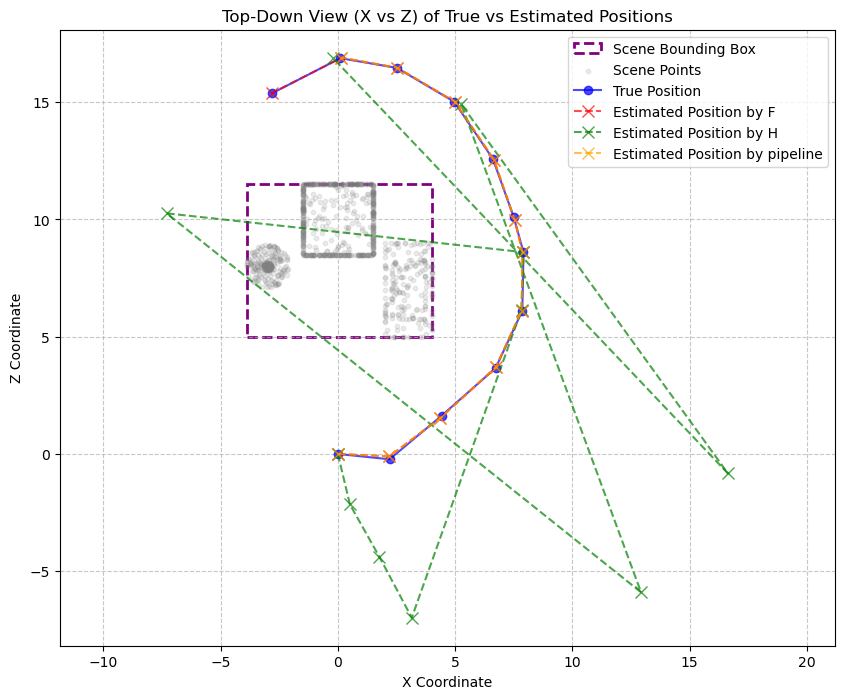

In [ ]:
scene_data = make_scene(scene_type="urban", cam2_rx=1, cam2_ry=1, cam2_rz=1, cam2_tx=20, cam2_ty=0, cam2_tz=20, cam1_tx = 20, cam1_tz =20)
pts3d_vis = scene_data['pts3d']
z_max = np.max(pts3d_vis[2,:])
z_min = np.min(pts3d_vis[2,:])
x_max = np.max(pts3d_vis[0,:])
x_min = np.min(pts3d_vis[0,:])

true_pos = np.zeros((nb_pose, 3))
est_pos_F = np.zeros((nb_pose, 3))
est_pos_H = np.zeros((nb_pose, 3))
est_pos_score = np.zeros((nb_pose, 3))

for i in range(nb_pose-1):
    true_pos[i+1, :] = translate_point(true_pos[0, :], true_t[i, :])
    est_pos_F[i+1, :] = translate_point(est_pos_F[0, :], est_t_F[i, :])
    est_pos_H[i+1, :] = translate_point(est_pos_H[0, :], est_t_H[i, :])
    est_pos_score[i+1, :] = translate_point(est_pos_score[0, :], est_t_score[i, :])

width = x_max - x_min
height = z_max - z_min

# --- Plotting ---
plt.figure(figsize=(10, 8))

# 1. Plot the Scene Bounding Box and Points
rect = patches.Rectangle(
    (x_min, z_min),  # (x, y) anchor point
    width,           # Width along X-axis
    height,          # Height along Z-axis
    linewidth=2,     
    edgecolor='purple', # Distinct color from your trajectories
    facecolor='none',
    label='Scene Bounding Box',
    linestyle='--'
)
plt.gca().add_patch(rect)

# Scatter the 3D points faintly in the background
plt.scatter(pts3d_vis[0, :], pts3d_vis[2, :], color='gray', alpha=0.15, s=10, label='Scene Points')

# 2. Plot True Positions
plt.plot(true_pos[:, 0], true_pos[:, 2], label='True Position', 
         color='blue', marker='o', linestyle='-', markersize=6, alpha=0.7)

# 3. Plot Estimated Positions
plt.plot(est_pos_F[:, 0], est_pos_F[:, 2], label='Estimated Position by F', 
         color='red', marker='x', linestyle='--', markersize=8, alpha=0.7)

plt.plot(est_pos_H[:, 0], est_pos_H[:, 2], label='Estimated Position by H', 
         color='green', marker='x', linestyle='--', markersize=8, alpha=0.7)

plt.plot(est_pos_score[:, 0], est_pos_score[:, 2], label='Estimated Position by pipeline', 
         color='orange', marker='x', linestyle='--', markersize=8, alpha=0.7)

# Formatting the plot
plt.title('Top-Down View (X vs Z) of True vs Estimated Positions')
plt.xlabel('X Coordinate')
plt.ylabel('Z Coordinate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Ensure the aspect ratio is equal so distances aren't distorted
plt.axis('equal') 

# Display the plot
plt.show()

In [ ]:
print(score_ratio)
print(est_t_F == est_t_score)


[0.20161672 0.14513349 0.15463048 0.16025458 0.05147172 0.06448745
 0.15259293 0.17501327 0.14296818 0.18633378 0.13467638 0.19988076
        nan        nan        nan        nan        nan        nan
        nan        nan]
[[ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]]


# Random scene

In [ ]:
nb_pose = 15

true_position, angle = generate_regular_polygon(nb_pose, 12, 0, 12)

true_t = np.full((nb_pose, 3), np.nan)
true_r = np.full((nb_pose, 3), np.nan)

est_t_F = np.full((nb_pose, 3), np.nan)
est_r_F = np.full((nb_pose, 3), np.nan)

est_t_H = np.full((nb_pose, 3), np.nan)
est_r_H = np.full((nb_pose, 3), np.nan)

est_t_score = np.full((nb_pose, 3), np.nan)
est_r_score = np.full((nb_pose, 3), np.nan)

score_ratio = np.full(nb_pose, np.nan)
ry = 0

Nb_points = 2000
window = 150
u_bound = 1000 + window
l_bound = 700 - window
for i in range(nb_pose - 1):
    noise1 = np.random.uniform(-1.5, 1.5)
    noise2 = np.random.uniform(-1.5, 1.5)
    noise3 = np.random.uniform(-7, 7)
    tx = true_position[i+1, 0] - true_position[0, 0] + noise1
    tz = true_position[i+1, 1] - true_position[0, 1] + noise2
    ry = -angle + noise3 -i*angle
    r2 = [0, ry, 0]
    t2 = [tx, 0, tz]
    true_t[i, :] = t2
    true_r[i, :] = r2
    nb_points = 0
    
    while nb_points < 50:
        scene_data = make_scene(n_points=Nb_points , cam2_rx=r2[0], cam2_ry=r2[1], cam2_rz=r2[2], cam2_tx=t2[0], cam2_ty=t2[1], cam2_tz=t2[2],
                                scene_type="planar", x_range= 3, y_range=5)
        px1_planar = scene_data['px1']
        px2_planar = scene_data['px2']
        px3d_planar = scene_data['pts3d']
        scene_data = make_scene(n_points=Nb_points - 150, cam2_rx=r2[0], cam2_ry=r2[1], cam2_rz=r2[2], cam2_tx=t2[0], cam2_ty=t2[1], cam2_tz=t2[2],
                                 x_range=10, y_range=10)
        px1_noplanar = scene_data['px1']
        px2_noplanar = scene_data['px2']
        px3d_noplanar = scene_data['pts3d']
        K = scene_data['K']
        R1 = np.eye(3)
        t1 = np.zeros((3,1))
        inside_mask = (px1_planar[0, :] >= l_bound) & (px1_planar[0, :] <= u_bound)
        outside_mask = (px1_noplanar[0, :] <= l_bound) | (px1_noplanar[0, :] >= u_bound)

        curr_px1_planar = px1_planar[:, inside_mask]
        curr_px2_planar = px2_planar[:, inside_mask]
        curr_px3d_planar = px3d_planar[:, inside_mask]
        
        curr_px1_noplanar = px1_noplanar[:, outside_mask]
        curr_px2_noplanar = px2_noplanar[:, outside_mask]
        curr_px3d_noplanar = px3d_noplanar[:, outside_mask]

        # 4. Stack the temporary variables safely
        px1_combined = np.hstack((curr_px1_planar, curr_px1_noplanar))
        px2_combined = np.hstack((curr_px2_planar, curr_px2_noplanar))
        px3d_combined = np.hstack((curr_px3d_planar, curr_px3d_noplanar))
        nb_points = px1_combined.shape[1]
        print(nb_points)

    px1_vis = px1_combined
    px2_vis = px2_combined
    pts3d_vis = px3d_combined
    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    # Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) 
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm

    est_rotation = get_angles_from_matrix(R2_hat) 
    est_translation = t2_hat.flatten()

    est_t_F[i, :] = est_translation
    est_r_F[i, :] = est_rotation

    S_F = score_F(F_Ransac, clean_px1, clean_px2)

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    R_H, t_H_norm = decompose_H(H_Ransac, K, plane_dist=5,
                                    X_ref=clean_p3d[:, 0])
    s = 1#np.linalg.norm(scene_data['t_rel'])
    t_H = s*t_H_norm
    
    est_rotation = get_angles_from_matrix(R_H) 
    est_translation = t_H.flatten()
    
    est_t_H[i, :] = est_translation
    est_r_H[i, :] = est_rotation

    S_H      = score_H(H_Ransac, clean_px1, clean_px2)    
    score_ratio[i] = S_H / (S_H + S_F)

    est_t_score[i, :] = est_t_H[i,:] if score_ratio[i] > 0.45 else est_t_F[i,:] 
    est_r_score[i, :] = est_r_H[i,:] if score_ratio[i] > 0.45 else est_r_F[i,:] 

    z_max = np.max(pts3d_vis[2,:])
    z_min = np.min(pts3d_vis[2,:])
    x_max = np.max(pts3d_vis[0,:])
    x_min = np.min(pts3d_vis[0,:])
    
    print(i)


    

997
0
975
1
985
2
938
3
960
4
979
5
946
6
988
7
966
8
984
9
902
10
728
11
1013
12
1067
13


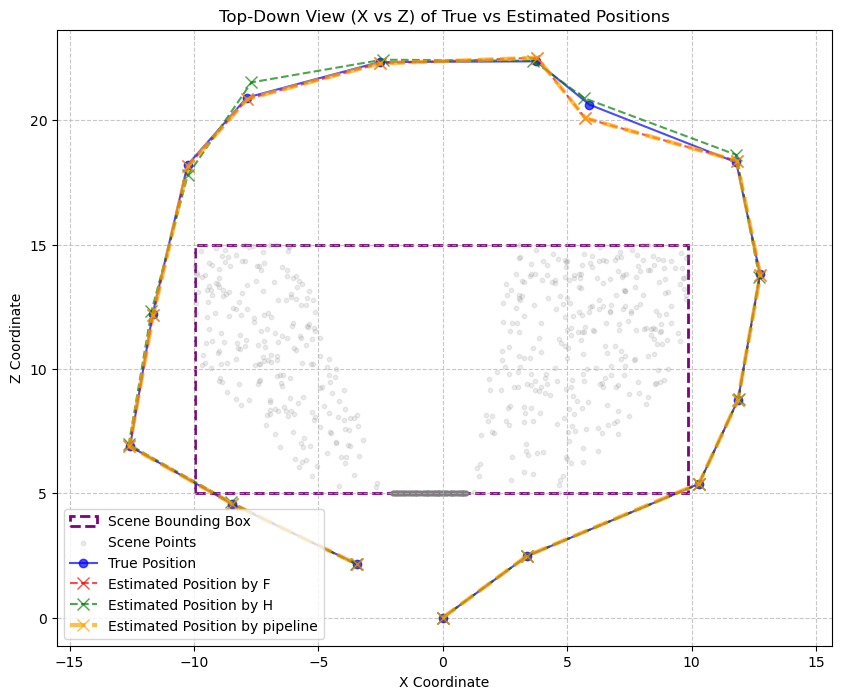

In [ ]:
true_pos = np.zeros((nb_pose, 3))
est_pos_F = np.zeros((nb_pose, 3))
est_pos_H = np.zeros((nb_pose, 3))
est_pos_score = np.zeros((nb_pose, 3))

for i in range(nb_pose-1):
    true_pos[i+1, :] = translate_point(true_pos[0, :], true_t[i, :])
    est_pos_F[i+1, :] = translate_point(est_pos_F[0, :], est_t_F[i, :])
    est_pos_H[i+1, :] = translate_point(est_pos_H[0, :], est_t_H[i, :])
    est_pos_score[i+1, :] = translate_point(est_pos_score[0, :], est_t_score[i, :])

width = x_max - x_min
height = z_max - z_min

# --- Plotting ---
plt.figure(figsize=(10, 8))

# 1. Plot the Scene Bounding Box and Points
rect = patches.Rectangle(
    (x_min, z_min),  # (x, y) anchor point
    width,           # Width along X-axis
    height,          # Height along Z-axis
    linewidth=2,     
    edgecolor='purple', # Distinct color from your trajectories
    facecolor='none',
    label='Scene Bounding Box',
    linestyle='--'
)
plt.gca().add_patch(rect)

# Scatter the 3D points faintly in the background
plt.scatter(pts3d_vis[0, :], pts3d_vis[2, :], color='gray', alpha=0.15, s=10, label='Scene Points')

# 2. Plot True Positions
plt.plot(true_pos[:, 0], true_pos[:, 2], label='True Position', 
         color='blue', marker='o', linestyle='-', markersize=6, alpha=0.7)

# 3. Plot Estimated Positions
plt.plot(est_pos_F[:, 0], est_pos_F[:, 2], label='Estimated Position by F', 
         color='red', marker='x', linestyle='--', markersize=8, alpha=0.7)

plt.plot(est_pos_H[:, 0], est_pos_H[:, 2], label='Estimated Position by H', 
         color='green', marker='x', linestyle='--', markersize=8, alpha=0.7)

plt.plot(est_pos_score[:, 0], est_pos_score[:, 2], label='Estimated Position by pipeline', 
         color='orange', linewidth=3, marker='x', linestyle='--', markersize=8, alpha=0.7)

# Formatting the plot
plt.title('Top-Down View (X vs Z) of True vs Estimated Positions')
plt.xlabel('X Coordinate')
plt.ylabel('Z Coordinate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Ensure the aspect ratio is equal so distances aren't distorted
plt.axis('equal') 

# Display the plot
plt.show()

In [ ]:
print(score_ratio)
print(est_t_F == est_t_score)


[0.45901519 0.0472413  0.22869589 0.360866   0.29000414 0.25821349
 0.27111376 0.23375333 0.23553577 0.23988084 0.31008285 0.37294969
 0.2537644  0.44432976        nan]
[[False False False]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [ True  True  True]
 [False False False]]


In [37]:
nb_pose = 15

true_position, angle = generate_regular_polygon(nb_pose, 12, 0, 12)

true_t = np.full((nb_pose, 3), np.nan)
true_r = np.full((nb_pose, 3), np.nan)

est_t_F = np.full((nb_pose, 3), np.nan)
est_r_F = np.full((nb_pose, 3), np.nan)

est_t_H = np.full((nb_pose, 3), np.nan)
est_r_H = np.full((nb_pose, 3), np.nan)

est_t_score = np.full((nb_pose, 3), np.nan)
est_r_score = np.full((nb_pose, 3), np.nan)

score_ratio = np.full(nb_pose, np.nan)
ry = 0

Nb_points = 2000
window = 300
u_bound = 1000 + window
l_bound = 700 - window
rx_curr = 0
ry_curr = 0
rz_curr = 0
tx_curr = 0
ty_curr = 0
tz_curr = 0
tx = 0
tz = 0
ry = 0

                           
max_point = 0
for i in range(nb_pose - 1):
    noise1 = np.random.uniform(-1.5, 1.5)
                           
    noise2 = np.random.uniform(-1.5, 1.5)
                           
    noise3 = np.random.uniform(-7, 7)
    ry = -angle + noise3 -i*angle
    r1 = [0, ry_curr, 0]
    t1 = [tx_curr, 0, tz_curr]
    tx = true_position[i+1, 0]  + noise1
    tz = true_position[i+1, 1] + noise2
    t2 = [tx, 0, tz]
    true_t[i, :] = t2
    true_r[i, :] = r2
    nb_points = 0
    
    while nb_points < 50:
        scene_data = make_scene(n_points=Nb_points , cam2_rx=r2[0], cam2_ry=r2[1], cam2_rz=r2[2], cam2_tx=t2[0], cam2_ty=t2[1], cam2_tz=t2[2],
                                scene_type="planar", x_range= 3, y_range=5, cam1_rx=r1[0], cam1_ry=r1[1], cam1_rz=r1[2], cam1_tx=t1[0], cam1_ty=t1[1], cam1_tz=t1[2], z_min=10)
        px1_planar = scene_data['px1']
        px2_planar = scene_data['px2']
        px3d_planar = scene_data['pts3d']
        scene_data = make_scene(n_points=Nb_points - 150, cam2_rx=r2[0], cam2_ry=r2[1], cam2_rz=r2[2], cam2_tx=t2[0], cam2_ty=t2[1], cam2_tz=t2[2],
                                 x_range=10, y_range=10, cam1_rx=r1[0], cam1_ry=r1[1], cam1_rz=r1[2], cam1_tx=t1[0], cam1_ty=t1[1], cam1_tz=t1[2])
        px1_noplanar = scene_data['px1']
        px2_noplanar = scene_data['px2']
        px3d_noplanar = scene_data['pts3d']
        K = scene_data['K']
        R1 = np.eye(3)
        t1 = np.zeros((3,1))
        inside_mask = np.full(px1_planar.shape[1], True)
        outside_mask = np.full(px1_noplanar.shape[1], True)

        curr_px1_planar = px1_planar[:, inside_mask]
        curr_px2_planar = px2_planar[:, inside_mask]
        curr_px3d_planar = px3d_planar[:, inside_mask]
        
        curr_px1_noplanar = px1_noplanar[:, outside_mask]
        curr_px2_noplanar = px2_noplanar[:, outside_mask]
        curr_px3d_noplanar = px3d_noplanar[:, outside_mask]

        # 4. Stack the temporary variables safely
        px1_combined = np.hstack((curr_px1_planar, curr_px1_noplanar))
        px2_combined = np.hstack((curr_px2_planar, curr_px2_noplanar))
        px3d_combined = np.hstack((curr_px3d_planar, curr_px3d_noplanar))
        nb_points = px1_combined.shape[1]
        print(nb_points)

    px1_vis = px1_combined
    px2_vis = px2_combined
    pts3d_vis = px3d_combined
    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    # Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) 
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm

    est_rotation = get_angles_from_matrix(R2_hat) 
    est_translation = t2_hat.flatten()

    est_t_F[i, :] = est_translation
    est_r_F[i, :] = est_rotation

    S_F = score_F(F_Ransac, clean_px1, clean_px2)

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    R_H, t_H_norm = decompose_H(H_Ransac, K, plane_dist=None,
                                    X_ref=clean_p3d[:, 0])
    s = 1#np.linalg.norm(scene_data['t_rel'])
    t_H = s*t_H_norm
    
    est_rotation = get_angles_from_matrix(R_H) 
    est_translation = t_H.flatten()
    
    est_t_H[i, :] = est_translation
    est_r_H[i, :] = est_rotation

    S_H      = score_H(H_Ransac, clean_px1, clean_px2)    
    score_ratio[i] = S_H / (S_H + S_F)

    est_t_score[i, :] = est_t_H[i,:] if score_ratio[i] > 0.45 else est_t_F[i,:] 
    est_r_score[i, :] = est_r_H[i,:] if score_ratio[i] > 0.45 else est_r_F[i,:] 
    if i == 0:
        z_max = np.max(pts3d_vis[2,:])
        z_min = np.min(pts3d_vis[2,:])
        x_max = np.max(pts3d_vis[0,:])
        x_min = np.min(pts3d_vis[0,:])
        keep_p3d = pts3d_vis
        max_point = nb_points
    ry_curr = r2[1]
    tx_curr = t2[0]
    tz_curr = t2[2]
    print(i)


1996
0
2144
1
2928
2
3348


KeyboardInterrupt: 

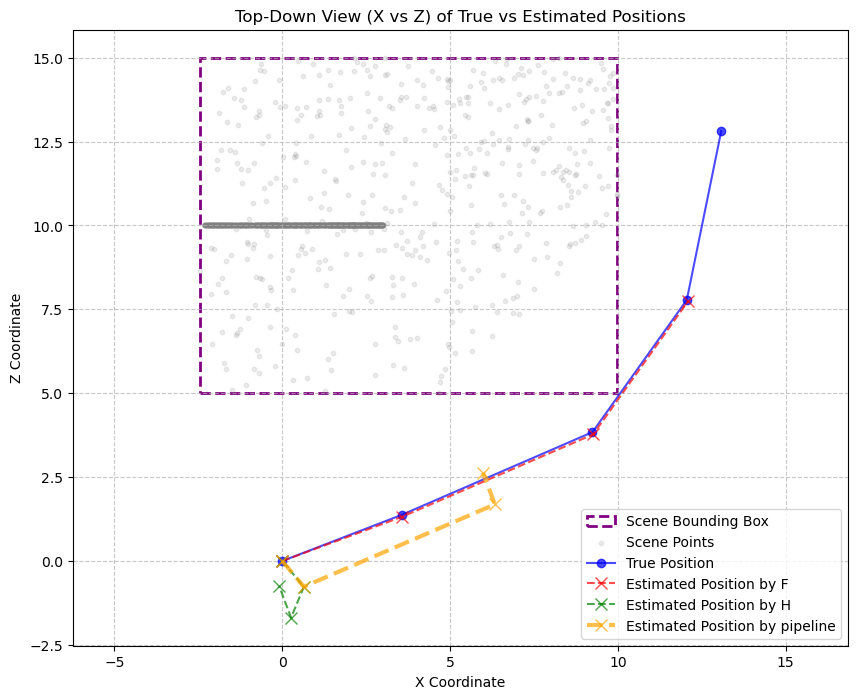

[[ 3.5631561   0.          1.37671234]
 [ 9.244463    0.          3.84149192]
 [12.05454245  0.          7.78055337]
 [13.08129165  0.         12.81495672]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]
 [        nan         nan         nan]]
[[ 6.44080870e-01 -8.29813295e-04 -7.64956955e-01]
 [ 5.69223508e+00  3.46412864e-04  2.45459483e+00]
 [-3.53240161e-01 -1.03988376e-02  9.35474881e-01]
 [            nan             nan             nan]
 [            nan             nan             nan]
 [            nan             nan             nan]
 [            nan             nan             nan]
 [            nan             nan             nan]
 [    

In [38]:
true_pos = np.zeros((nb_pose, 3))
est_pos_F = np.zeros((nb_pose, 3))
est_pos_H = np.zeros((nb_pose, 3))
est_pos_score = np.zeros((nb_pose, 3))

for i in range(nb_pose-1):
    true_pos[i+1, :] = translate_point(true_pos[0, :], true_t[i, :])
    est_pos_F[i+1, :] = translate_point(est_pos_F[i, :], est_t_F[i, :])
    est_pos_H[i+1, :] = translate_point(est_pos_H[i, :], est_t_H[i, :])
    est_pos_score[i+1, :] = translate_point(est_pos_score[i, :], est_t_score[i, :])

width = x_max - x_min
height = z_max - z_min

# --- Plotting ---
plt.figure(figsize=(10, 8))

# 1. Plot the Scene Bounding Box and Points
rect = patches.Rectangle(
    (x_min, z_min),  # (x, y) anchor point
    width,           # Width along X-axis
    height,          # Height along Z-axis
    linewidth=2,     
    edgecolor='purple', # Distinct color from your trajectories
    facecolor='none',
    label='Scene Bounding Box',
    linestyle='--'
)
plt.gca().add_patch(rect)

# Scatter the 3D points faintly in the background
plt.scatter(keep_p3d[0, :], keep_p3d[2, :], color='gray', alpha=0.15, s=10, label='Scene Points')

# 2. Plot True Positions
plt.plot(true_pos[:, 0], true_pos[:, 2], label='True Position', 
         color='blue', marker='o', linestyle='-', markersize=6, alpha=0.7)

# 3. Plot Estimated Positions
plt.plot(est_pos_F[:, 0], est_pos_F[:, 2], label='Estimated Position by F', 
         color='red', marker='x', linestyle='--', markersize=8, alpha=0.7)

plt.plot(est_pos_H[:, 0], est_pos_H[:, 2], label='Estimated Position by H', 
         color='green', marker='x', linestyle='--', markersize=8, alpha=0.7)

plt.plot(est_pos_score[:, 0], est_pos_score[:, 2], label='Estimated Position by pipeline', 
         color='orange', linewidth=3, marker='x', linestyle='--', markersize=8, alpha=0.7)

# Formatting the plot
plt.title('Top-Down View (X vs Z) of True vs Estimated Positions')
plt.xlabel('X Coordinate')
plt.ylabel('Z Coordinate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Ensure the aspect ratio is equal so distances aren't distorted
plt.axis('equal') 

# Display the plot
plt.show()
print(true_t)
print(est_t_score)

In [39]:
print(score_ratio)
print(est_t_F == est_t_score)


[0.51755268 0.40917963 0.48656424        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan]
[[False False False]
 [ True  True  True]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]
 [False False False]]


In [68]:
nb_pose = 20

true_position, angle = generate_regular_polygon(nb_pose, 3, 0, 3)

true_t = np.full((nb_pose, 3), np.nan)
true_r = np.full((nb_pose, 3), np.nan)

est_t_F = np.full((nb_pose, 3), np.nan)
est_r_F = np.full((nb_pose, 3), np.nan)

est_t_H = np.full((nb_pose, 3), np.nan)
est_r_H = np.full((nb_pose, 3), np.nan)

est_t_score = np.full((nb_pose, 3), np.nan)
est_r_score = np.full((nb_pose, 3), np.nan)

score_ratio = np.full(nb_pose, np.nan)
ry = 0
r1 = [0, 0, 0]
t1 = [0, 0, 0]
for i in range(nb_pose - 1):
    noise1 = np.random.uniform(-0.75, 0.75)
    noise2 = np.random.uniform(-0.75, 0.75)
    noise3 = np.random.uniform(-7, 7)
    tx = true_position[i+1, 0] - true_position[0, 0] + noise1
    tz = true_position[i+1, 1] - true_position[0, 1] + noise2
    ry = 0
    r2 = [0, ry, 0]
    t2 = [tx, 0, tz]
    true_t[i, :] = t2
    true_r[i, :] = r2
    
    scene_data = make_scene(scene_type="urban", cam2_rx=r2[0], cam2_ry=r2[1], cam2_rz=r2[2], cam2_tx=t2[0], cam2_ty=t2[1], cam2_tz=t2[2],
                            cam1_rx=r1[0], cam1_ry=r1[1], cam1_rz=r1[2], cam1_tx=t1[0], cam1_ty=t1[1], cam1_tz=t1[2])
    pts3d_vis = scene_data['pts3d']
    px1_vis = scene_data['px1']
    px2_vis = scene_data['px2']
    K = scene_data['K']
    R1 = np.eye(3)
    t1 = np.zeros((3,1))
    nb_points = px1_vis.shape[1]
    
    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    # Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) 
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm

    est_rotation = get_angles_from_matrix(R2_hat) 
    est_translation = t2_hat.flatten()

    est_t_F[i, :] = est_translation
    est_r_F[i, :] = est_rotation

    S_F = score_F(F_Ransac, clean_px1, clean_px2)

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    R_H, t_H_norm = decompose_H(H_Ransac, K, plane_dist=None,
                                    X_ref=clean_p3d[:, 0])
    s = np.linalg.norm(scene_data['t_rel'])
    t_H = s*t_H_norm
    
    est_rotation = get_angles_from_matrix(R_H) 
    est_translation = t_H.flatten()
    
    est_t_H[i, :] = est_translation
    est_r_H[i, :] = est_rotation

    S_H      = score_H(H_Ransac, clean_px1, clean_px2)    
    score_ratio[i] = S_H / (S_H + S_F)

    est_t_score[i, :] = est_t_H[i,:] if score_ratio[i] > 0.45 else est_t_F[i,:] 
    est_r_score[i, :] = est_r_H[i,:] if score_ratio[i] > 0.45 else est_r_F[i,:] 

    r1[1] = r2[1]
    t1[0] = t2[0]
    t1[2] = t2[2]
    print(i)



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18


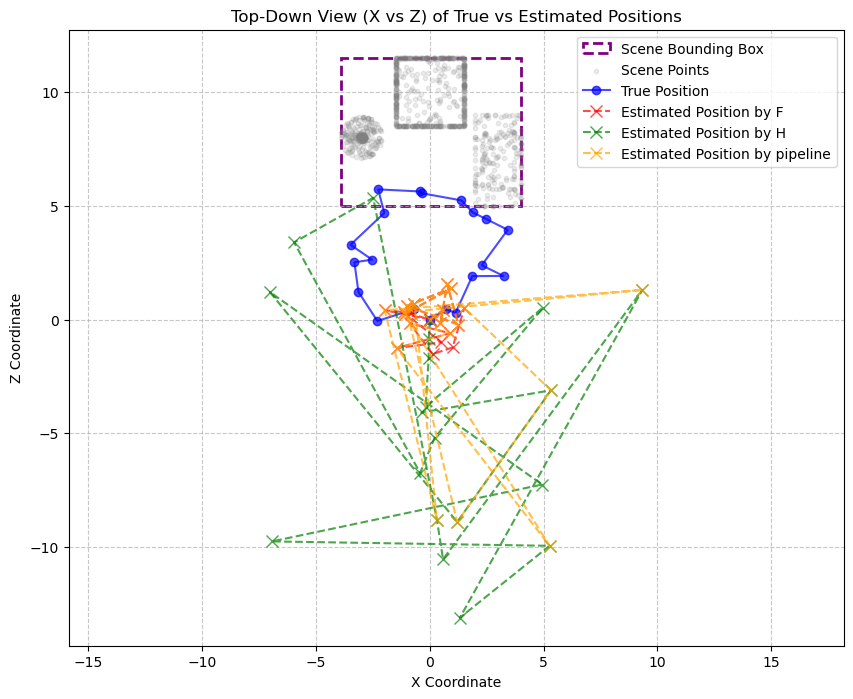

In [69]:
scene_data = make_scene(scene_type="urban", cam2_rx=1, cam2_ry=1, cam2_rz=1, cam2_tx=20, cam2_ty=0, cam2_tz=20, cam1_tx = 20, cam1_tz =20)
pts3d_vis = scene_data['pts3d']
z_max = np.max(pts3d_vis[2,:])
z_min = np.min(pts3d_vis[2,:])
x_max = np.max(pts3d_vis[0,:])
x_min = np.min(pts3d_vis[0,:])

true_pos = np.zeros((nb_pose, 3))
est_pos_F = np.zeros((nb_pose, 3))
est_pos_H = np.zeros((nb_pose, 3))
est_pos_score = np.zeros((nb_pose, 3))

for i in range(nb_pose-1):
    true_pos[i+1, :] = translate_point(true_pos[0, :], true_t[i, :])
    est_pos_F[i+1, :] = translate_point(est_pos_F[0, :], est_t_F[i, :])
    est_pos_H[i+1, :] = translate_point(est_pos_H[0, :], est_t_H[i, :])
    est_pos_score[i+1, :] = translate_point(est_pos_score[0, :], est_t_score[i, :])

width = x_max - x_min
height = z_max - z_min

# --- Plotting ---
plt.figure(figsize=(10, 8))

# 1. Plot the Scene Bounding Box and Points
rect = patches.Rectangle(
    (x_min, z_min),  # (x, y) anchor point
    width,           # Width along X-axis
    height,          # Height along Z-axis
    linewidth=2,     
    edgecolor='purple', # Distinct color from your trajectories
    facecolor='none',
    label='Scene Bounding Box',
    linestyle='--'
)
plt.gca().add_patch(rect)

# Scatter the 3D points faintly in the background
plt.scatter(pts3d_vis[0, :], pts3d_vis[2, :], color='gray', alpha=0.15, s=10, label='Scene Points')

# 2. Plot True Positions
plt.plot(true_pos[:, 0], true_pos[:, 2], label='True Position', 
         color='blue', marker='o', linestyle='-', markersize=6, alpha=0.7)

# 3. Plot Estimated Positions
plt.plot(est_pos_F[:, 0], est_pos_F[:, 2], label='Estimated Position by F', 
         color='red', marker='x', linestyle='--', markersize=8, alpha=0.7)

plt.plot(est_pos_H[:, 0], est_pos_H[:, 2], label='Estimated Position by H', 
         color='green', marker='x', linestyle='--', markersize=8, alpha=0.7)

plt.plot(est_pos_score[:, 0], est_pos_score[:, 2], label='Estimated Position by pipeline', 
         color='orange', marker='x', linestyle='--', markersize=8, alpha=0.7)

# Formatting the plot
plt.title('Top-Down View (X vs Z) of True vs Estimated Positions')
plt.xlabel('X Coordinate')
plt.ylabel('Z Coordinate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Ensure the aspect ratio is equal so distances aren't distorted
plt.axis('equal') 

# Display the plot
plt.show()

In [91]:
nb_pose = 15

true_position, angle = generate_regular_polygon(nb_pose, 4, 0, 4)

true_t = np.full((nb_pose, 3), np.nan)
true_r = np.full((nb_pose, 3), np.nan)

est_t_F = np.full((nb_pose, 3), np.nan)
est_r_F = np.full((nb_pose, 3), np.nan)

est_t_H = np.full((nb_pose, 3), np.nan)
est_r_H = np.full((nb_pose, 3), np.nan)

est_t_score = np.full((nb_pose, 3), np.nan)
est_r_score = np.full((nb_pose, 3), np.nan)

score_ratio = np.full(nb_pose, np.nan)
ry = 0

Nb_points = 2000
window = 150
u_bound = 1000 + window
l_bound = 700 - window
rx_curr = 0
ry_curr = 0
rz_curr = 0
tx_curr = 0
ty_curr = 0
tz_curr = 0
tx = 0
tz = 0
ry = 0

                           
max_point = 0
for i in range(nb_pose - 1):
    noise1 = np.random.uniform(-0.25, 0.25)
                           
    noise2 = np.random.uniform(-0.25, 0.25)
                           
    noise3 = np.random.uniform(-7, 7)
    ry = 0
    r1 = [0, ry_curr, 0]
    t1 = [tx_curr, 0, tz_curr]
    tx = true_position[i+1, 0]  + noise1
    tz = true_position[i+1, 1] + noise2
    t2 = [tx, 0, tz]
    true_t[i, :] = t2
    true_r[i, :] = r2
    nb_points = 0
    
    while nb_points < 50:
        scene_data = make_scene(n_points=Nb_points , cam2_rx=r2[0], cam2_ry=r2[1], cam2_rz=r2[2], cam2_tx=t2[0], cam2_ty=t2[1], cam2_tz=t2[2],
                                scene_type="planar", x_range= 2, y_range=5, cam1_rx=r1[0], cam1_ry=r1[1], cam1_rz=r1[2], cam1_tx=t1[0], cam1_ty=t1[1], cam1_tz=t1[2], z_min=10)
        px1_planar = scene_data['px1']
        px2_planar = scene_data['px2']
        px3d_planar = scene_data['pts3d']
        d1 = scene_data['d1']
        scene_data = make_scene(n_points=Nb_points , cam2_rx=r2[0], cam2_ry=r2[1], cam2_rz=r2[2], cam2_tx=t2[0], cam2_ty=t2[1], cam2_tz=t2[2],
                                 x_range=10, y_range=10, cam1_rx=r1[0], cam1_ry=r1[1], cam1_rz=r1[2], cam1_tx=t1[0], cam1_ty=t1[1], cam1_tz=t1[2])
        px1_noplanar = scene_data['px1']
        px2_noplanar = scene_data['px2']
        px3d_noplanar = scene_data['pts3d']
        K = scene_data['K']
        R1 = np.eye(3)
        t1 = np.zeros((3,1))
        inside_mask = (px1_planar[0, :] >= l_bound) & (px1_planar[0, :] <= u_bound)
        outside_mask = (px1_noplanar[0, :] <= l_bound) | (px1_noplanar[0, :] >= u_bound)

        curr_px1_planar = px1_planar[:, inside_mask]
        curr_px2_planar = px2_planar[:, inside_mask]
        curr_px3d_planar = px3d_planar[:, inside_mask]
        
        curr_px1_noplanar = px1_noplanar[:, outside_mask]
        curr_px2_noplanar = px2_noplanar[:, outside_mask]
        curr_px3d_noplanar = px3d_noplanar[:, outside_mask]

        # 4. Stack the temporary variables safely
        px1_combined = np.hstack((curr_px1_planar, curr_px1_noplanar))
        px2_combined = np.hstack((curr_px2_planar, curr_px2_noplanar))
        px3d_combined = np.hstack((curr_px3d_planar, curr_px3d_noplanar))
        nb_points = px1_combined.shape[1]
        print(nb_points)

    px1_vis = px1_combined
    px2_vis = px2_combined
    pts3d_vis = px3d_combined
    ransac_solver_F = RANSAC(
        s=8, 
        score_fct=score_F_RANSAC,
        model_fct=eight_point, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    F_Ransac, mask = ransac_solver_F.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    tf, R_1f, R_2f = get_R_t_from_epipolar(F_Ransac, K = K) 

    # Estrimate the projection matrix
    P_estf = P_estimation(tf, R_1f, R_2f, K) 
    R2_hat, t2_norm, P2_norm = parallax(P_estf, K, clean_px1, clean_px2)
    s = find_scaling_factor(P2_norm, K, clean_px1, clean_px2, clean_p3d)
    t2_hat = s*t2_norm

    est_rotation = get_angles_from_matrix(R2_hat) 
    est_translation = t2_hat.flatten()

    est_t_F[i, :] = est_translation
    est_r_F[i, :] = est_rotation

    S_F = score_F(F_Ransac, clean_px1, clean_px2)

    ransac_solver_H = RANSAC(
        s=4, 
        score_fct=score_H_RANSAC,
        model_fct=homography, 
        px1=px1_vis, 
        px2=px2_vis,
        epsilon=None
        )
    H_Ransac, mask = ransac_solver_H.execute_RANSAC()
    clean_px1 = px1_vis[:, mask]
    clean_px2 = px2_vis[:, mask]
    clean_p3d = pts3d_vis[:, mask]
    R_H, t_H_norm = decompose_H(H_Ransac, K, plane_dist=d1[0],
                                    X_ref=clean_p3d[:, 0])
    s = 1#np.linalg.norm(scene_data['t_rel'])
    t_H = s*t_H_norm
    
    est_rotation = get_angles_from_matrix(R_H) 
    est_translation = t_H.flatten()
    
    est_t_H[i, :] = est_translation
    est_r_H[i, :] = est_rotation

    S_H      = score_H(H_Ransac, clean_px1, clean_px2)    
    score_ratio[i] = S_H / (S_H + S_F)

    est_t_score[i, :] = est_t_H[i,:] if score_ratio[i] > 0.45 else est_t_F[i,:] 
    est_r_score[i, :] = est_r_H[i,:] if score_ratio[i] > 0.45 else est_r_F[i,:] 
    if i == 0:
        z_max = np.max(pts3d_vis[2,:])
        z_min = np.min(pts3d_vis[2,:])
        x_max = np.max(pts3d_vis[0,:])
        x_min = np.min(pts3d_vis[0,:])
        keep_p3d = pts3d_vis
        max_point = nb_points
    ry_curr = r2[1]
    tx_curr = t2[0]
    tz_curr = t2[2]
    print(i)
    print(score_ratio[i])


2520
0
0.5842661667953916
1670
1
0.5639838312384683
1241
2
0.5109296398220655
887
3
0.37699122249136746
1162
4
0.43190852564578847
1577
5
0.4643763947981681
2346
6
0.5545916782271436
2828
7
0.5839506474998692
2817
8
0.6113873598742974
2805
9
0.5964022466976762
2702
10
0.6047814624385267
2576
11
0.606975905663957
2254
12
0.6153185882279495
2526
13
0.55738684435578


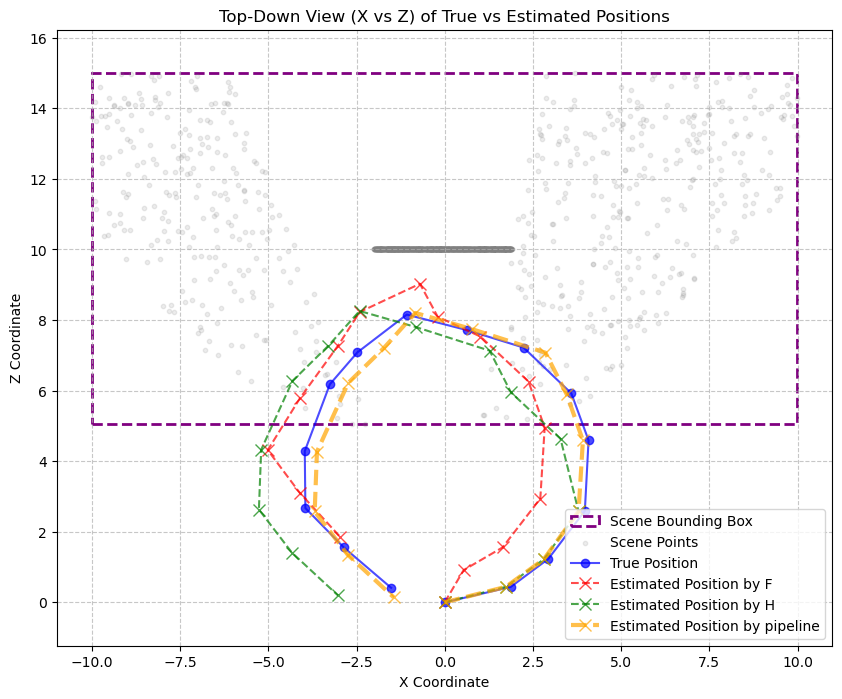

[[ 1.86764629  0.          0.43544178]
 [ 2.93448891  0.          1.23077401]
 [ 3.97056499  0.          2.5920362 ]
 [ 4.07550296  0.          4.59153411]
 [ 3.58687132  0.          5.92324711]
 [ 2.23407188  0.          7.21951874]
 [ 0.64090077  0.          7.71069265]
 [-1.07679259  0.          8.15375895]
 [-2.47670208  0.          7.08129756]
 [-3.25479307  0.          6.17992594]
 [-3.96649504  0.          4.28383607]
 [-3.94918362  0.          2.6707882 ]
 [-2.85974286  0.          1.55520878]
 [-1.51945784  0.          0.41152361]
 [        nan         nan         nan]]
[[ 1.73268774 -0.10979714  0.44045483]
 [ 1.07319857 -0.03797438  0.77937336]
 [ 0.98600131 -0.0662498   1.35744916]
 [ 0.1233843   0.03589153  2.00963434]
 [-0.4579996   0.01429442  1.30506148]
 [-0.60540781  0.2530156   1.18333442]
 [-2.0904388  -0.02372124  0.66960125]
 [-1.59321573 -0.37815453  0.45564834]
 [-0.88803659  0.26040472 -0.98901246]
 [-1.0161546   0.26690349 -0.99505455]
 [-0.88517129  0.2917964

In [92]:
true_pos = np.zeros((nb_pose, 3))
est_pos_F = np.zeros((nb_pose, 3))
est_pos_H = np.zeros((nb_pose, 3))
est_pos_score = np.zeros((nb_pose, 3))

for i in range(nb_pose-1):
    true_pos[i+1, :] = translate_point(true_pos[0, :], true_t[i, :])
    est_pos_F[i+1, :] = translate_point(est_pos_F[i, :], est_t_F[i, :])
    est_pos_H[i+1, :] = translate_point(est_pos_H[i, :], est_t_H[i, :])
    est_pos_score[i+1, :] = translate_point(est_pos_score[i, :], est_t_score[i, :])

width = x_max - x_min
height = z_max - z_min

# --- Plotting ---
plt.figure(figsize=(10, 8))

# 1. Plot the Scene Bounding Box and Points
rect = patches.Rectangle(
    (x_min, z_min),  # (x, y) anchor point
    width,           # Width along X-axis
    height,          # Height along Z-axis
    linewidth=2,     
    edgecolor='purple', # Distinct color from your trajectories
    facecolor='none',
    label='Scene Bounding Box',
    linestyle='--'
)
plt.gca().add_patch(rect)

# Scatter the 3D points faintly in the background
plt.scatter(keep_p3d[0, :], keep_p3d[2, :], color='gray', alpha=0.15, s=10, label='Scene Points')

# 2. Plot True Positions
plt.plot(true_pos[:, 0], true_pos[:, 2], label='True Position', 
         color='blue', marker='o', linestyle='-', markersize=6, alpha=0.7)

# 3. Plot Estimated Positions
plt.plot(est_pos_F[:, 0], est_pos_F[:, 2], label='Estimated Position by F', 
         color='red', marker='x', linestyle='--', markersize=8, alpha=0.7)

plt.plot(est_pos_H[:, 0], est_pos_H[:, 2], label='Estimated Position by H', 
         color='green', marker='x', linestyle='--', markersize=8, alpha=0.7)

plt.plot(est_pos_score[:, 0], est_pos_score[:, 2], label='Estimated Position by pipeline', 
         color='orange', linewidth=3, marker='x', linestyle='--', markersize=8, alpha=0.7)

# Formatting the plot
plt.title('Top-Down View (X vs Z) of True vs Estimated Positions')
plt.xlabel('X Coordinate')
plt.ylabel('Z Coordinate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Ensure the aspect ratio is equal so distances aren't distorted
plt.axis('equal') 

# Display the plot
plt.show()
print(true_t)
print(est_t_score)

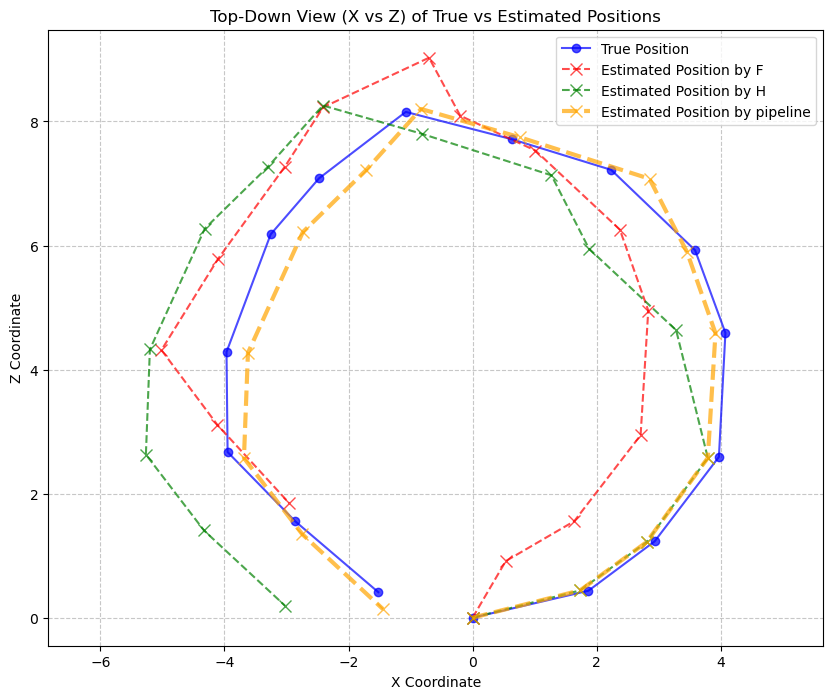

[0.58426617 0.56398383 0.51092964 0.37699122 0.43190853 0.46437639
 0.55459168 0.58395065 0.61138736 0.59640225 0.60478146 0.60697591
 0.61531859 0.55738684        nan]


In [93]:
plt.figure(figsize=(10, 8))

# 2. Plot True Positions
plt.plot(true_pos[:, 0], true_pos[:, 2], label='True Position', 
         color='blue', marker='o', linestyle='-', markersize=6, alpha=0.7)

# 3. Plot Estimated Positions
plt.plot(est_pos_F[:, 0], est_pos_F[:, 2], label='Estimated Position by F', 
         color='red', marker='x', linestyle='--', markersize=8, alpha=0.7)

plt.plot(est_pos_H[:, 0], est_pos_H[:, 2], label='Estimated Position by H', 
         color='green', marker='x', linestyle='--', markersize=8, alpha=0.7)

plt.plot(est_pos_score[:, 0], est_pos_score[:, 2], label='Estimated Position by pipeline', 
         color='orange', linewidth=3, marker='x', linestyle='--', markersize=8, alpha=0.7)

# Formatting the plot
plt.title('Top-Down View (X vs Z) of True vs Estimated Positions')
plt.xlabel('X Coordinate')
plt.ylabel('Z Coordinate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Ensure the aspect ratio is equal so distances aren't distorted
plt.axis('equal') 

# Display the plot
plt.show()
print(score_ratio)

In [100]:
errors = np.linalg.norm(est_pos_score[:, [0, 2]] - true_pos[:, [0, 2]], axis=1)
RMSE_ATE_score = np.sqrt(np.mean(errors**2))
errors_F = np.linalg.norm(est_pos_F[:, [0, 2]] - true_pos[:, [0, 2]], axis=1)
RMSE_ATE_F = np.sqrt(np.mean(errors_F**2))
errors_H = np.linalg.norm(est_pos_H[:, [0, 2]] - true_pos[:, [0, 2]], axis=1)
RMSE_ATE_H = np.sqrt(np.mean(errors_H**2))

print(RMSE_ATE_score)
print(RMSE_ATE_F)
print(RMSE_ATE_H)

true_deltas = np.diff(true_pos, axis=0)
est_deltas  = np.diff(est_pos_score, axis=0)

# 2. Calculate the magnitude of the error vector for each step
error_vectors = est_deltas - true_deltas
rte_raw = np.linalg.norm(error_vectors, axis=1) # Error in units (e.g. meters)

# 3. Calculate normalized RTE (Error as a percentage of step length)
step_lengths = np.linalg.norm(true_deltas, axis=1)
rte_percent = (rte_raw / step_lengths) * 100

# 4. Final Metric: Mean RTE
mean_rte = np.mean(rte_percent)
print(f"Average Relative Translation Error: {mean_rte:.2f}%")

# F matrix
true_deltas = np.diff(true_pos, axis=0)
est_deltas  = np.diff(est_pos_F, axis=0)

# 2. Calculate the magnitude of the error vector for each step
error_vectors = est_deltas - true_deltas
rte_raw = np.linalg.norm(error_vectors, axis=1) # Error in units (e.g. meters)

# 3. Calculate normalized RTE (Error as a percentage of step length)
step_lengths = np.linalg.norm(true_deltas, axis=1)
rte_percent = (rte_raw / step_lengths) * 100

# 4. Final Metric: Mean RTE
mean_rte = np.mean(rte_percent)
print(f"Average Relative Translation Error: {mean_rte:.2f}%")

# H matrix
true_deltas = np.diff(true_pos, axis=0)
est_deltas  = np.diff(est_pos_H, axis=0)

# 2. Calculate the magnitude of the error vector for each step
error_vectors = est_deltas - true_deltas
rte_raw = np.linalg.norm(error_vectors, axis=1) # Error in units (e.g. meters)

# 3. Calculate normalized RTE (Error as a percentage of step length)
step_lengths = np.linalg.norm(true_deltas, axis=1)
rte_percent = (rte_raw / step_lengths) * 100

# 4. Final Metric: Mean RTE
mean_rte = np.mean(rte_percent)
print(f"Average Relative Translation Error: {mean_rte:.2f}%")



0.34479455010604115
1.3880124702972636
1.0986030334048222
Average Relative Translation Error: 16.31%
Average Relative Translation Error: 25.55%
Average Relative Translation Error: 22.79%


In [99]:
import numpy as np
from scipy.spatial.transform import Rotation as R

def calculate_step_rre(true_angles, est_angles):
    """
    Calculates the Relative Rotation Error (RRE) in degrees.
    true_angles, est_angles: [rx, ry, rz] in degrees
    """
    # 1. Convert Euler angles to Rotation Matrices
    # Using 'xyz' or 'zyx' depending on your simulator's convention
    r_true = R.from_euler('xyz', true_angles, degrees=True).as_matrix()
    r_est = R.from_euler('xyz', est_angles, degrees=True).as_matrix()
    
    # 2. Compute the relative rotation matrix
    # This represents the "rotation difference"
    r_diff = np.dot(r_true.T, r_est)
    
    # 3. Calculate the angle of this rotation (the Geodesic distance)
    # Formula: acos((trace(R_diff) - 1) / 2)
    cos_theta = (np.trace(r_diff) - 1.0) / 2.0
    
    # Clip to avoid floating point errors outside [-1, 1]
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    
    return np.degrees(np.arccos(cos_theta))

# --- Application ---
# Assuming est_r_score and true_r are arrays of shape (nb_pose, 3)
rre_per_step = []

for i in range(nb_pose - 1):
    # We compare the estimated rotation of the step to the true rotation
    error = calculate_step_rre(true_r[i], est_r_score[i])
    rre_per_step.append(error)

mean_rre = np.mean(rre_per_step)
print(f"Mean Relative Rotation Error: {mean_rre:.4f} degrees per step")

rre_per_step = []
# F
for i in range(nb_pose - 1):
    # We compare the estimated rotation of the step to the true rotation
    error = calculate_step_rre(true_r[i], est_r_F[i])
    rre_per_step.append(error)

mean_rre = np.mean(rre_per_step)
print(f"Mean Relative Rotation Error: {mean_rre:.4f} degrees per step")

# H
for i in range(nb_pose - 1):
    # We compare the estimated rotation of the step to the true rotation
    error = calculate_step_rre(true_r[i], est_r_H[i])
    rre_per_step.append(error)

mean_rre = np.mean(rre_per_step)
print(f"Mean Relative Rotation Error: {mean_rre:.4f} degrees per step")

Mean Relative Rotation Error: 0.9949 degrees per step
Mean Relative Rotation Error: 1.5193 degrees per step
Mean Relative Rotation Error: 1.4706 degrees per step
